### Import

In [1]:
import os
import gc
import time
import scipy
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 
from datasets import load_from_disk
from sklearn import metrics
from sklearn.utils import resample
from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

### Path

In [2]:
path_cohort   = "../Data/Cohorts/"
path_results  = "../Results/"

### Read Cohort

In [3]:
with open(path_cohort + "icustays_ehr_text", "rb") as fp:   
    icustays_ehr_text = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_only", "rb") as fp:   
    icustays_ehr_only = pickle.load(fp)

### Read Results

In [4]:
lstm = pd.read_csv(path_results + 'LLM_LSTM_Result.csv')
lstm_ff = pd.read_csv(path_results + 'TimeVariant.csv')
llm = pd.read_csv(path_results + 'LSTM_LLM_FF_Result.csv')

In [5]:
lstm = lstm[['stay_id', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
lstm_ff = lstm_ff[['stay_id', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
llm = llm[['stay_id', 'Predicted_Probability', 'Predicted_Label', 'icu_expire_flag']]

lstm.columns = ['stay_id', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
lstm_ff.columns = ['stay_id', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
llm.columns = ['stay_id',  'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']

In [6]:
llm.head(2)

### Select Patients

In [7]:
lstm = lstm[lstm.stay_id.isin(llm.stay_id.unique())]
lstm_ff = lstm_ff[lstm_ff.stay_id.isin(llm.stay_id.unique())]
llm = llm[llm.stay_id.isin(llm.stay_id.unique())]

### ROC

In [8]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [9]:
def get_roc_ci(y_true, y_score):
    
    auc_scores = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            fpr, tpr, _ = metrics.roc_curve(yte_true_b, yte_pred_b)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            auc_scores.append(metrics.roc_auc_score(yte_true_b, yte_pred_b))
            
        except Exception as e:
            continue
    
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    
    tprs_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)
    
    auc = roc_auc_score(y_true, y_score)
    
    return mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc

In [10]:
def plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label='Mean ROC (AUC = %0.2f)' % np.mean(auc_ci))
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.3)
    
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Chance', alpha=0.8)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [11]:
mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci = get_roc_ci(lstm['icu_expire_flag'], lstm['PREDICT_PROB'])

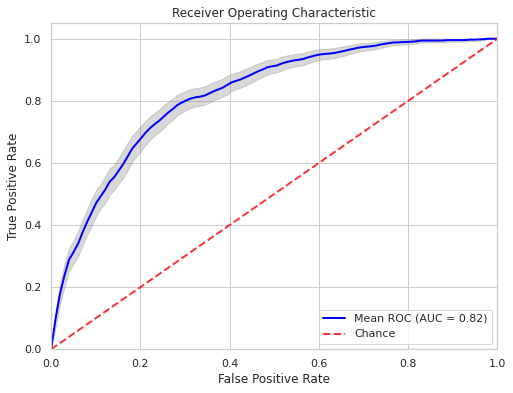

In [12]:
plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci)

### Precision-Recall

In [13]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [14]:
def get_prc_ci(y_true, y_score):
    
    prc_scores = []
    precisions = []
    recalls = []
    thresholds = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            precision, recall, _ = metrics.precision_recall_curve(yte_true_b, yte_pred_b)
            prc_score = metrics.auc(recall, precision)
            prc_scores.append(prc_score)
            interp_precision = np.interp(thresholds, recall[::-1], precision[::-1])
            precisions.append(interp_precision)
        except Exception as e:

            continue

    mean_precision = np.mean(precisions, axis=0)
    std_precision = np.std(precisions, axis=0)

    precision_upper = np.minimum(mean_precision + 1.64 * std_precision, 1)
    precision_lower = np.maximum(mean_precision - 1.64 * std_precision, 0)
    
    ap = average_precision_score(y_true, y_score)
    
    return thresholds, mean_precision, precision_lower, precision_upper, ap

In [15]:
def plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))

    plt.plot(thresholds, mean_precision, color='blue', lw=2, label='Mean PRC (AP = %0.2f)' % np.mean(prc_ci))
    plt.fill_between(thresholds, precision_lower, precision_upper, color='grey', alpha=0.3,)
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [16]:
thresholds, mean_precision, precision_lower, precision_upper, prc_ci = get_prc_ci(lstm['icu_expire_flag'], lstm['PREDICT_PROB'])

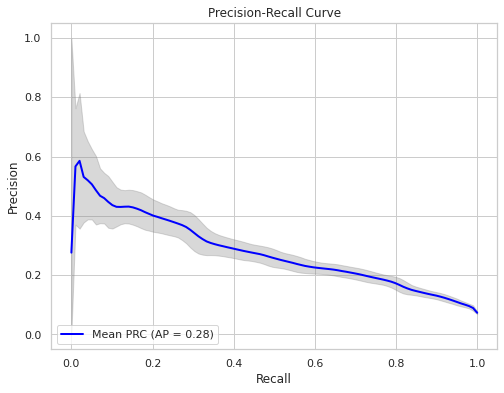

In [17]:
plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci)

### Performance Metrics

In [22]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    Brier = brier_score_loss(true_label, prediction_prob)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))
    print("Brier = " , np.round(Brier,  2))

In [23]:
def Performance_Metrics_CI(true_label, predicted_label, prediction_prob, n_bootstraps=1000, ci=95):
    
    metrics = {
        'ACC': [], 'PRC': [], 'REC': [], 'F1M': [], 'PPV': [],
        'NPV': [], 'SEN': [], 'SPE': [], 'FPR': [], 'FNR': [],
        'FDR': [], 'AUC': [], 'AP': [],  'MCC': [], 'BRR': []}
    
    for i in range(n_bootstraps):
        
        indices = resample(np.arange(len(true_label)), random_state=i)
        true_resampled = np.array(true_label)[indices]
        pred_resampled = np.array(predicted_label)[indices]
        prob_resampled = np.array(prediction_prob)[indices]
        
        TN, FP, FN, TP = confusion_matrix(true_resampled, pred_resampled).ravel()
        metrics['ACC'].append((TP + TN) / (TP + FP + FN + TN))
        metrics['PRC'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['REC'].append(TP / (TP + FN) if TP + FN > 0 else 0)
        metrics['F1M'].append((2 * metrics['PRC'][-1] * metrics['REC'][-1]) / (metrics['PRC'][-1] + metrics['REC'][-1]) if metrics['PRC'][-1] + metrics['REC'][-1] > 0 else 0)
        metrics['PPV'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['NPV'].append(TN / (TN + FN) if TN + FN > 0 else 0)
        metrics['SEN'].append(metrics['REC'][-1])
        metrics['SPE'].append(TN / (TN + FP) if TN + FP > 0 else 0)
        metrics['FPR'].append(FP / (FP + TN) if FP + TN > 0 else 0)
        metrics['FNR'].append(FN / (TP + FN) if TP + FN > 0 else 0)
        metrics['FDR'].append(FP / (TP + FP) if TP + FP > 0 else 0)
        metrics['AUC'].append(roc_auc_score(true_resampled, prob_resampled))
        metrics['AP'].append(average_precision_score(true_resampled, prob_resampled))
        metrics['MCC'].append(matthews_corrcoef(true_resampled, pred_resampled))
        metrics['BRR'].append(brier_score_loss(true_resampled, prob_resampled))

    ci_bounds = {}
    for key in metrics:
        lower = np.percentile(metrics[key], (100 - ci) / 2)
        upper = np.percentile(metrics[key], 100 - (100 - ci) / 2)
        mean  = np.mean(metrics[key])
        ci_bounds[key] = (mean, lower, upper)

    for metric, values in ci_bounds.items():
        print(f"{metric} = {values[0]:.3f} ({values[1]:.3f}-{values[2]:.3f})")

In [24]:
Performance_Metrics_CI(lstm['icu_expire_flag'], lstm['PREDICT_LABEL'], lstm['PREDICT_PROB'])

ACC = 0.710 (0.700-0.720)
PRC = 0.175 (0.161-0.189)
REC = 0.799 (0.768-0.829)
F1M = 0.287 (0.267-0.306)
PPV = 0.175 (0.161-0.189)
NPV = 0.978 (0.974-0.981)
SEN = 0.799 (0.768-0.829)
SPE = 0.703 (0.693-0.713)
FPR = 0.297 (0.287-0.307)
FNR = 0.201 (0.171-0.232)
FDR = 0.825 (0.811-0.839)
AUC = 0.819 (0.803-0.834)
AP = 0.282 (0.249-0.315)
MCC = 0.277 (0.258-0.298)
BRR = 0.215 (0.209-0.221)


In [25]:
Performance_Metrics_CI(lstm_ff['icu_expire_flag'], lstm_ff['PREDICT_LABEL'], lstm_ff['PREDICT_PROB'])

ACC = 0.831 (0.824-0.839)
PRC = 0.277 (0.258-0.297)
REC = 0.812 (0.784-0.842)
F1M = 0.413 (0.390-0.437)
PPV = 0.277 (0.258-0.297)
NPV = 0.982 (0.979-0.986)
SEN = 0.812 (0.784-0.842)
SPE = 0.833 (0.825-0.840)
FPR = 0.167 (0.160-0.175)
FNR = 0.188 (0.158-0.216)
FDR = 0.723 (0.703-0.742)
AUC = 0.906 (0.895-0.916)
AP = 0.482 (0.443-0.520)
MCC = 0.409 (0.388-0.432)
BRR = 0.307 (0.300-0.314)


In [26]:
Performance_Metrics_CI(llm['icu_expire_flag'], llm['PREDICT_LABEL'], llm['PREDICT_PROB'])

ACC = 0.861 (0.854-0.868)
PRC = 0.320 (0.297-0.342)
REC = 0.799 (0.768-0.828)
F1M = 0.456 (0.430-0.481)
PPV = 0.320 (0.297-0.342)
NPV = 0.982 (0.979-0.985)
SEN = 0.799 (0.768-0.828)
SPE = 0.866 (0.858-0.873)
FPR = 0.134 (0.127-0.142)
FNR = 0.201 (0.172-0.232)
FDR = 0.680 (0.658-0.703)
AUC = 0.913 (0.903-0.923)
AP = 0.507 (0.467-0.547)
MCC = 0.448 (0.424-0.472)
BRR = 0.058 (0.055-0.061)


### Plotting Probability Distributions

In [27]:
def plot_kde(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    sns.kdeplot(data[labels == 0], label='Survived', shade=True)
    sns.kdeplot(data[labels == 1], label='Deceased', shade=True)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Predicted Probability', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend()
    plt.show()

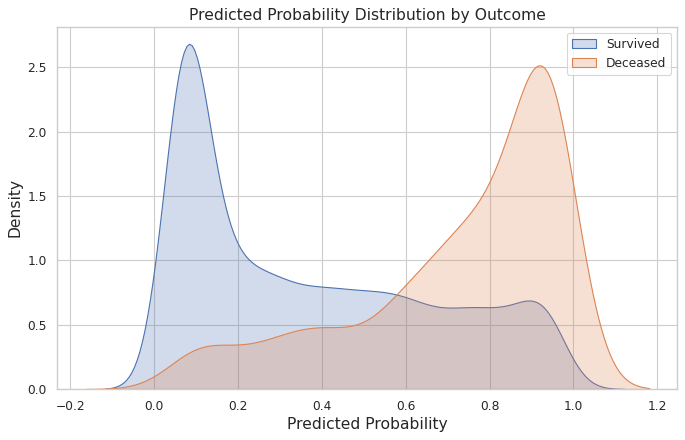

In [28]:
plot_kde(lstm['PREDICT_PROB'], lstm['icu_expire_flag'])

In [29]:
def plot_violin(data, labels):
    
    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.violinplot(x=labels, y=data, palette="muted", split=True)
    ax.set_xticklabels(['Survived', 'Deceased'])
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

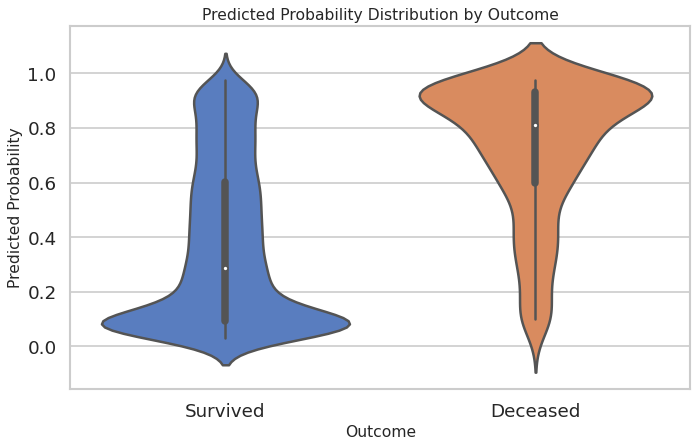

In [30]:
plot_violin(lstm['PREDICT_PROB'], lstm['icu_expire_flag'])

In [31]:
def plot_box(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.boxplot(x=labels, y=data, palette="muted")
    ax.set_xticklabels(['Survived', 'Deceased'], fontsize= 14)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

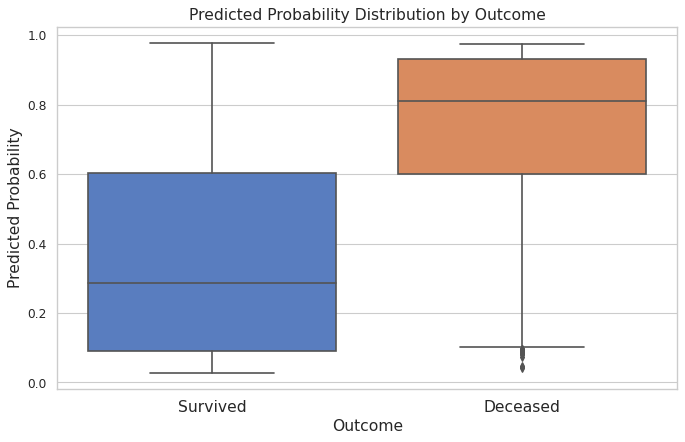

In [32]:
plot_box(lstm['PREDICT_PROB'], lstm['icu_expire_flag'])

### Plot ROC All

In [33]:
lstm_mean_fpr, lstm_mean_tpr, lstm_tprs_lower, lstm_tprs_upper, lstm_auc_ci = get_roc_ci(lstm['icu_expire_flag'], lstm['PREDICT_PROB'])
lstm_ff_mean_fpr, lstm_ff_mean_tpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, lstm_ff_auc_ci = get_roc_ci(lstm_ff['icu_expire_flag'], lstm_ff['PREDICT_PROB'])
llm_mean_fpr, llm_mean_tpr, llm_tprs_lower, llm_tprs_upper, llm_auc_ci = get_roc_ci(llm['icu_expire_flag'], llm['PREDICT_PROB'])

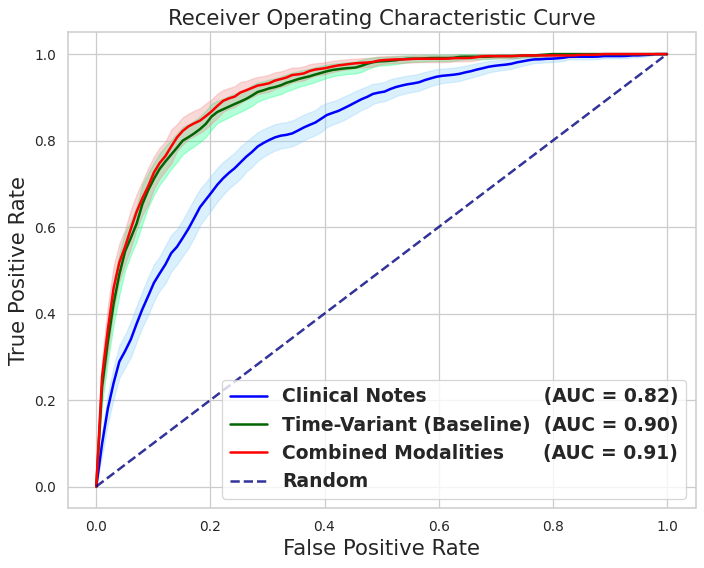

In [39]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_mean_fpr, lstm_mean_tpr, color='blue', lw=2, label='Clinical Notes                  (AUC = %0.2f)' % np.mean(lstm_auc_ci))
plt.fill_between(lstm_mean_fpr, lstm_tprs_lower, lstm_tprs_upper, color='lightskyblue', alpha=0.3)

plt.plot(lstm_ff_mean_fpr, lstm_ff_mean_tpr, color='darkgreen', lw=2, label='Time-Variant (Baseline)  (AUC = %0.2f)' % (np.mean(lstm_ff_auc_ci)))
plt.fill_between(lstm_ff_mean_fpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, color='springgreen', alpha=0.3)

plt.plot(llm_mean_fpr, llm_mean_tpr, color='red', lw=2, label='Combined Modalities      (AUC = %0.2f)' % (np.mean(llm_auc_ci) ))
plt.fill_between(llm_mean_fpr, llm_tprs_lower, llm_tprs_upper, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

### Plot Precision-Recall All

In [35]:
lstm_thresholds, lstm_mean_precision, lstm_precision_lower, lstm_precision_upper, lstm_prc_ci = get_prc_ci(lstm['icu_expire_flag'], lstm['PREDICT_PROB'])
lstm_ff_thresholds, lstm_ff_mean_precision, lstm_ff_precision_lower, lstm_ff_precision_upper, lstm_ff_prc_ci = get_prc_ci(lstm_ff['icu_expire_flag'], lstm_ff['PREDICT_PROB'])
llm_thresholds, llm_mean_precision, llm_precision_lower, llm_precision_upper, llm_prc_ci = get_prc_ci(llm['icu_expire_flag'], llm['PREDICT_PROB'])

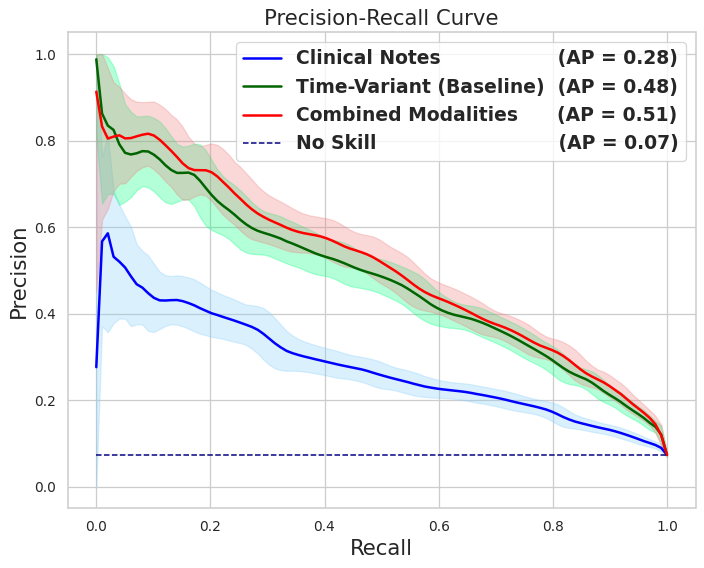

In [43]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_thresholds, lstm_mean_precision, color='blue', lw=2, label='Clinical Notes                  (AP = %0.2f)' % np.mean(lstm_prc_ci))
plt.fill_between(lstm_thresholds, lstm_precision_lower, lstm_precision_upper, color='lightskyblue', alpha=0.3,)

plt.plot(lstm_ff_thresholds, lstm_ff_mean_precision, color='darkgreen', lw=2, label='Time-Variant (Baseline)  (AP = %0.2f)' % np.mean(lstm_ff_prc_ci))
plt.fill_between(lstm_ff_thresholds, lstm_ff_precision_lower, lstm_ff_precision_upper, color='springgreen', alpha=0.3,)

plt.plot(llm_thresholds, llm_mean_precision, color='red', lw=2, label='Combined Modalities      (AP = %0.2f)' % np.mean(llm_prc_ci))
plt.fill_between(llm_thresholds, llm_precision_lower, llm_precision_upper, color='lightcoral', alpha=0.3,)

true_label = np.array(lstm['icu_expire_flag'])

no_skill = len(true_label[true_label == 1]) / len(true_label)
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill                            (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()